In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

# Mục mới

In [2]:
import pandas as pd

df = pd.read_csv('../data/heart.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [5]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

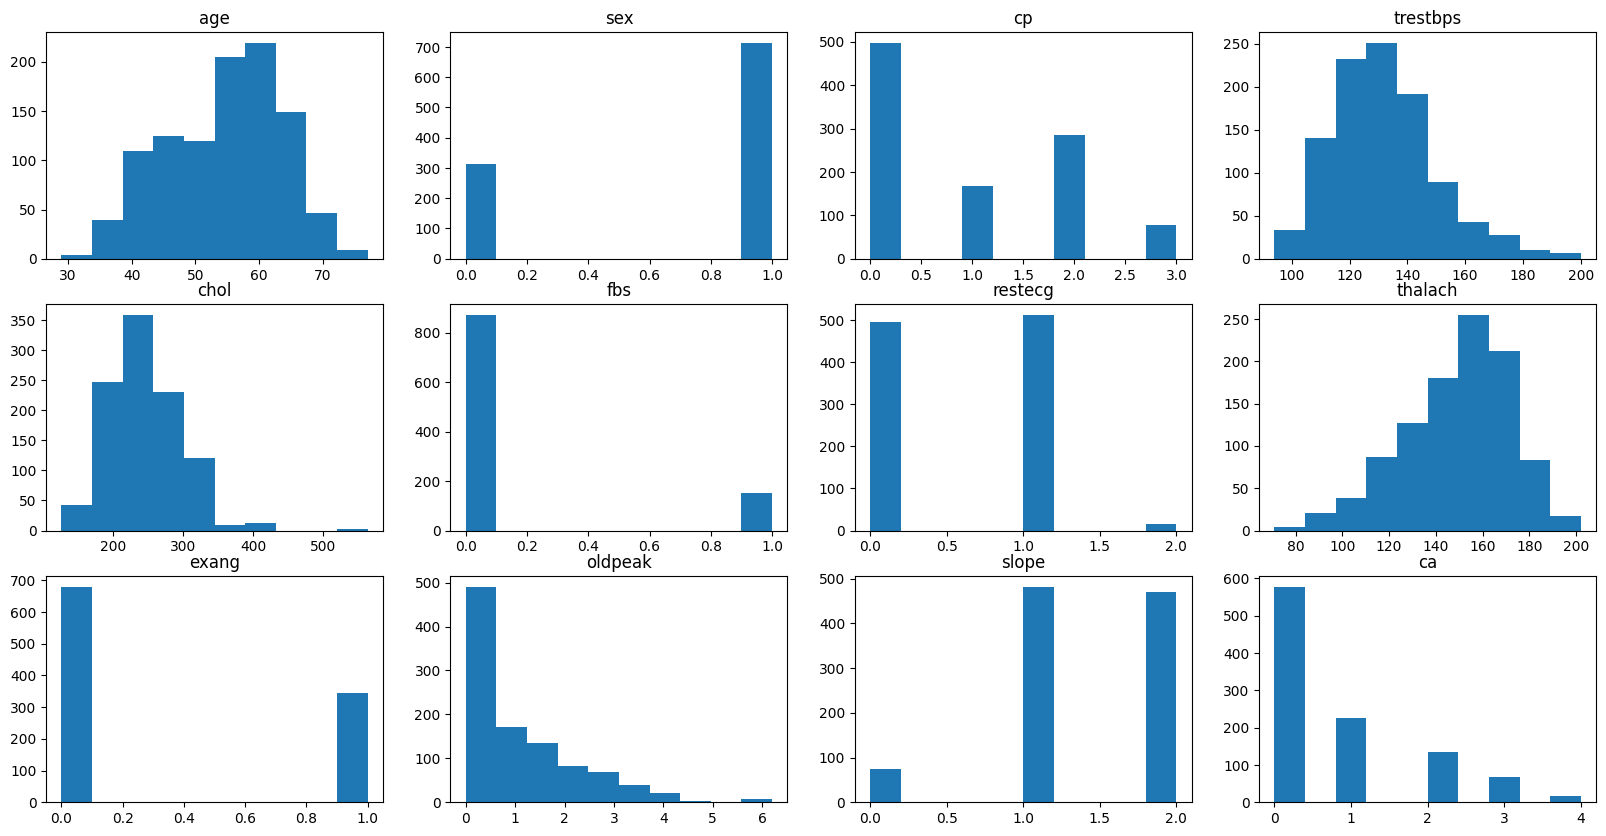

In [6]:
figure, axis = plt.subplots(3, 4,figsize=(20, 10))
axis[0,0].hist(df['age'])
axis[0,0].set_title('age')
axis[0,1].hist(df['sex'])
axis[0,1].set_title('sex')
axis[0,2].hist(df['cp'])
axis[0,2].set_title('cp')
axis[0,3].hist(df['trestbps'])
axis[0,3].set_title('trestbps')
axis[1,0].hist(df['chol'])
axis[1,0].set_title('chol')
axis[1,1].hist(df['fbs'])
axis[1,1].set_title('fbs')
axis[1,2].hist(df['restecg'])
axis[1,2].set_title('restecg')
axis[1,3].hist(df['thalach'])
axis[1,3].set_title('thalach')
axis[2,0].hist(df['exang'])
axis[2,0].set_title('exang')
axis[2,1].hist(df['oldpeak'])
axis[2,1].set_title('oldpeak')
axis[2,2].hist(df['slope'])
axis[2,2].set_title('slope')
axis[2,3].hist(df['ca'])
axis[2,3].set_title('ca')
plt.show()

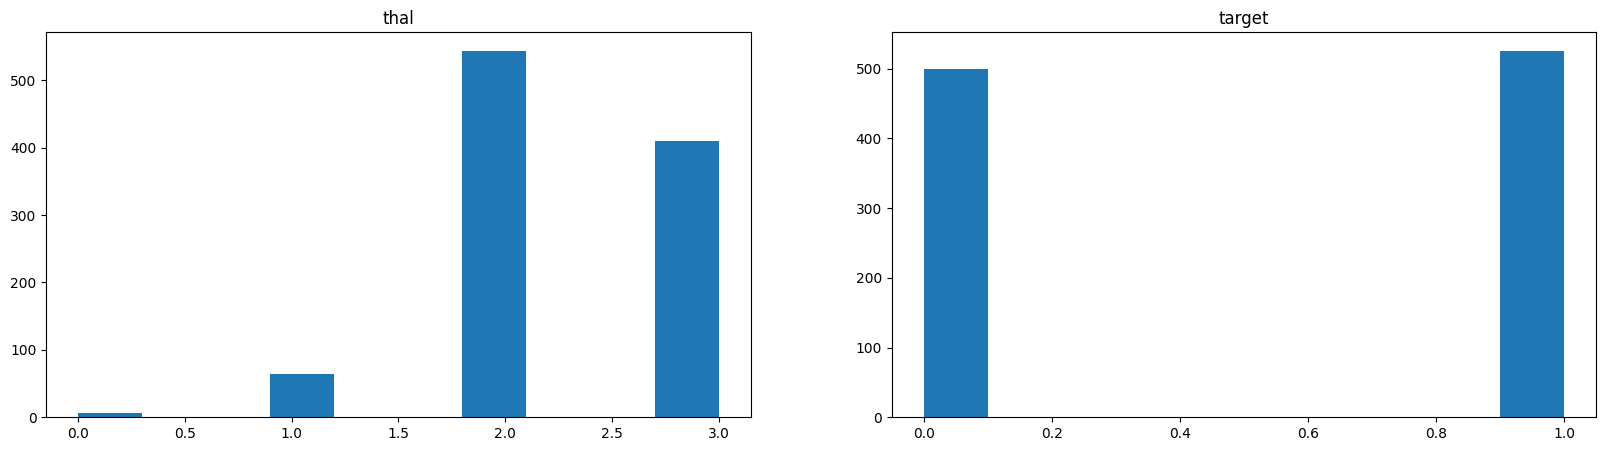

In [7]:
fixgure, axis = plt.subplots(1, 2, figsize=(20, 5))
axis[0].hist(df['thal'])
axis[0].set_title('thal')
axis[1].hist(df['target'])
axis[1].set_title('target')
plt.show()

## Correlation Heatmap

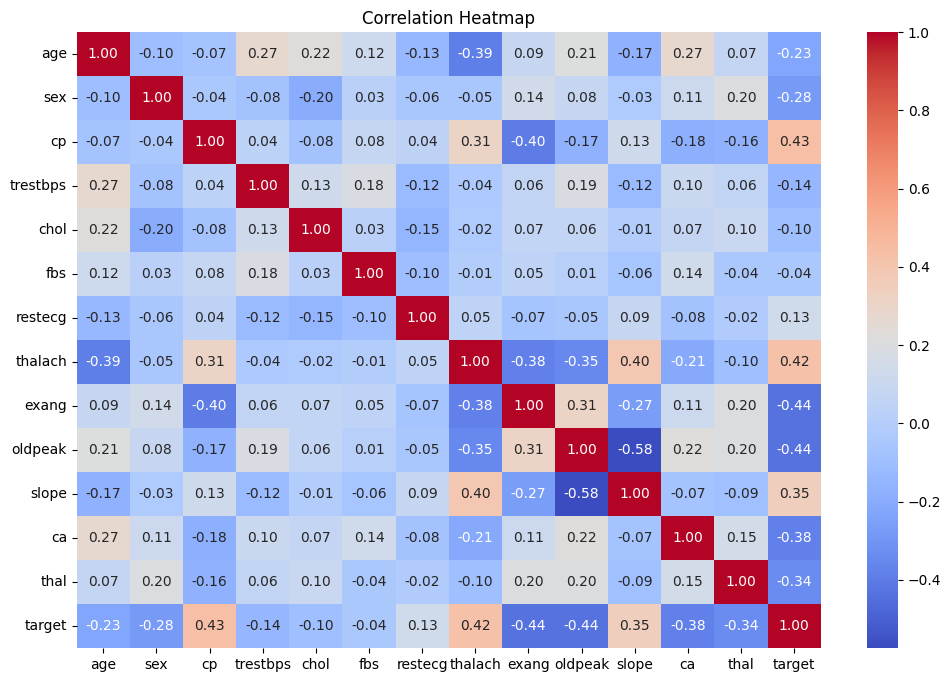

In [8]:

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


tiến hành xử lý dữ liệu để triển khai mô hình


In [9]:
x = df.drop('target', axis=1)
y = df['target']

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((820, 13), (205, 13), (820,), (205,))

Độ chính xác của Decision Tree: 98.54%
Confusion Matrix:
 [[102   0]
 [  3 100]]
Độ nhạy (Recall): 0.97
Độ đặc hiệu (Specificity): 1.00
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



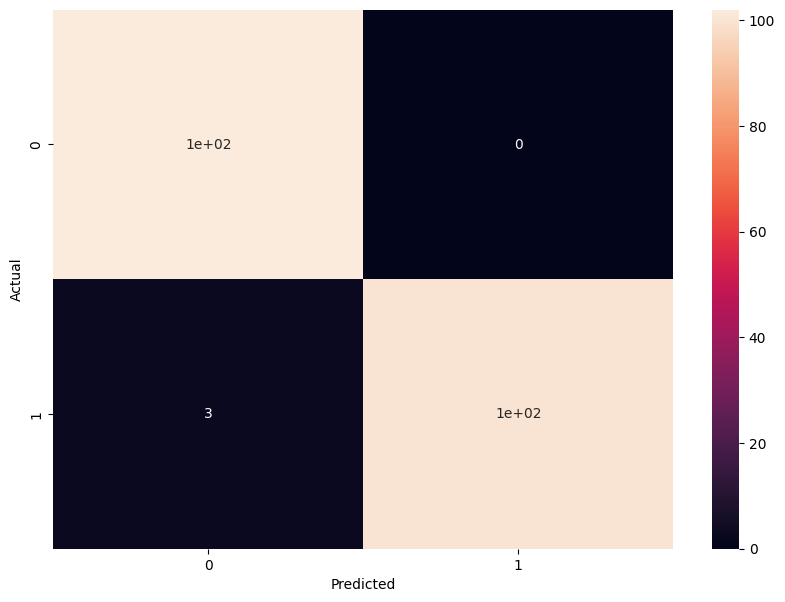

In [11]:
model_dt = DecisionTreeClassifier(random_state=42)
model_dt.fit(x_train, y_train)

y_pred_dt = model_dt.predict(x_test)
cm = confusion_matrix(y_test, y_pred_dt)
accuracy = accuracy_score(y_test, y_pred_dt)
print(f"Độ chính xác của Decision Tree: {accuracy*100:.2f}%")
print("Confusion Matrix:\n", cm)
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Actual')
tn, fp, fn, tp = cm.ravel()
recall = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f"Độ nhạy (Recall): {recall:.2f}")
print(f"Độ đặc hiệu (Specificity): {specificity:.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred_dt))

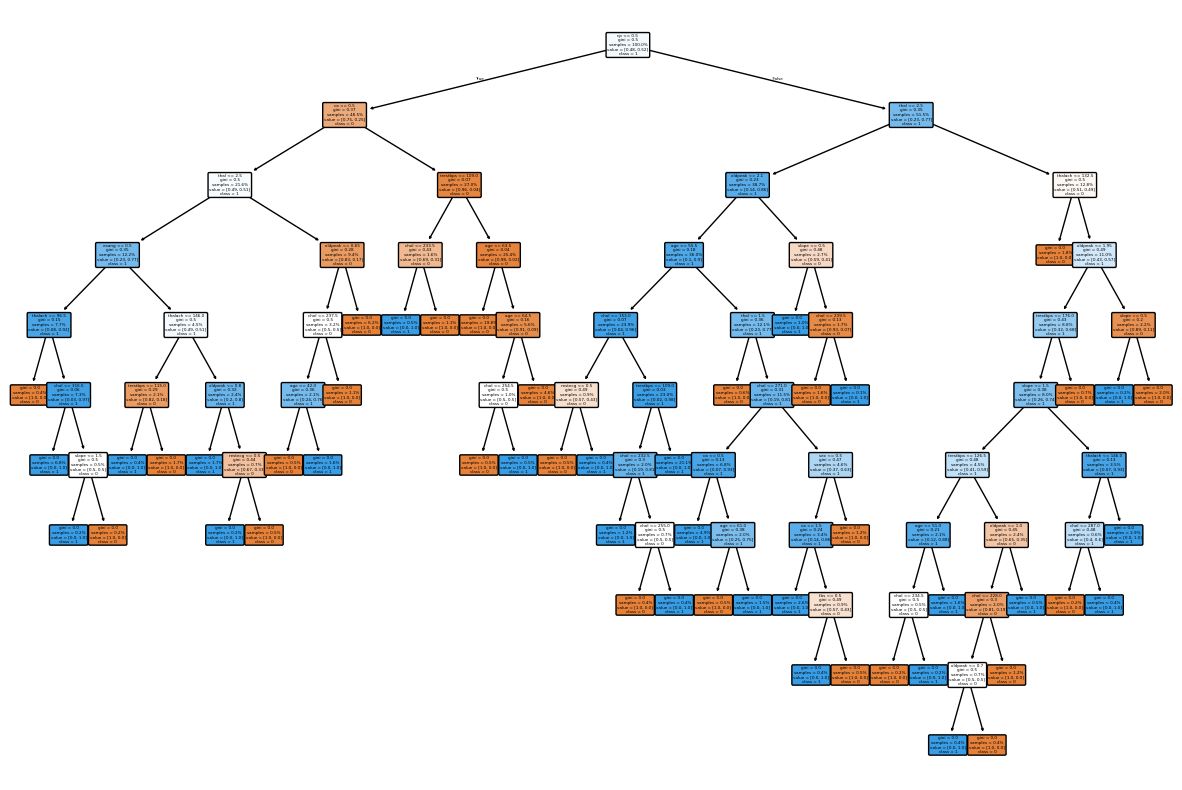

In [12]:
#in cay quyết định
plt.figure(figsize=(15,10))
plot_tree(model_dt,
          filled=True,
          feature_names=x.columns,
          class_names=['0', '1'],
          fontsize=3,  # Tăng kích thước font chữ
          rounded=True, # Làm tròn các góc của node
          proportion=True, # Điều chỉnh kích thước node theo tỷ lệ mẫu
          precision=2)  # Giới hạn số chữ số thập phân cho các giá trị
plt.show()

#so sánh so với các mô hình khác


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [14]:
# Logistic Regression
logit_model = LogisticRegression(max_iter=1000)
logit_model.fit(x_train, y_train)
pred_logit = logit_model.predict(x_test)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
pred_rf = rf_model.predict(x_test)

# KNN
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train)
pred_knn = knn_model.predict(x_test)


=== Logistic Regression ===
Confusion Matrix:
 [[73 29]
 [13 90]]
Độ chính xác: 0.7951219512195122
Độ nhạy (Recall): 0.87
Độ đặc hiệu (Specificity): 0.72
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205


=== Random Forest ===
Confusion Matrix:
 [[102   0]
 [  3 100]]
Độ chính xác: 0.9853658536585366
Độ nhạy (Recall): 0.97
Độ đặc hiệu (Specificity): 1.00
Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99  

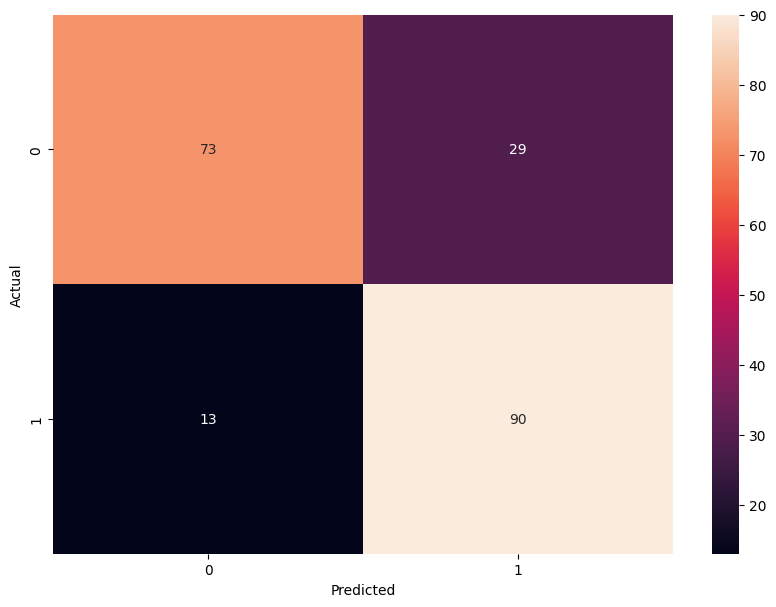

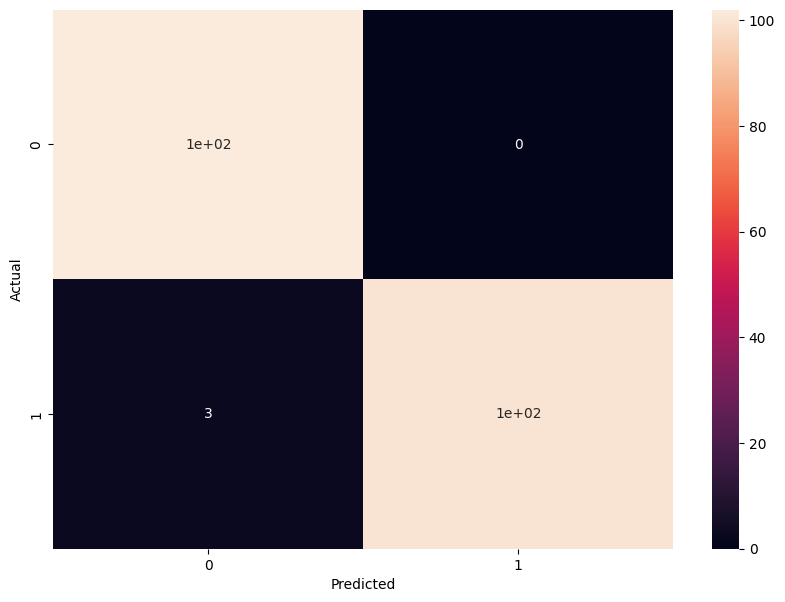

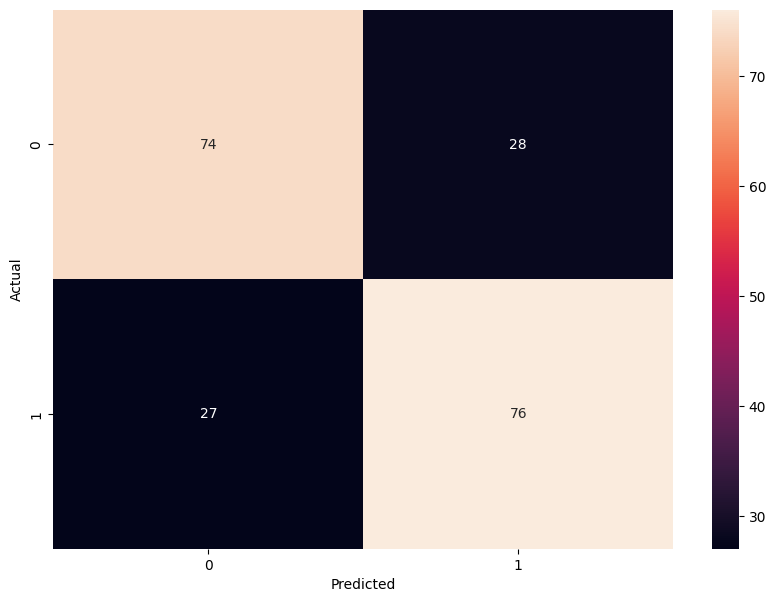

In [15]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    plt.figure(figsize=(10,7))
    sns.heatmap(confusion_matrix(y_true, y_pred),annot=True)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    print("Độ chính xác:", accuracy_score(y_true, y_pred))
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    recall = tp / (tp + fn)
    specificity = tn / (tn + fp)
    print(f"Độ nhạy (Recall): {recall:.2f}")
    print(f"Độ đặc hiệu (Specificity): {specificity:.2f}")
    print("Classification Report:\n", classification_report(y_true, y_pred))
evaluate_model("Logistic Regression", y_test, pred_logit)
evaluate_model("Random Forest", y_test, pred_rf)
evaluate_model("K-Nearest Neighbors", y_test, pred_knn)

## Feature Importance (Random Forest)

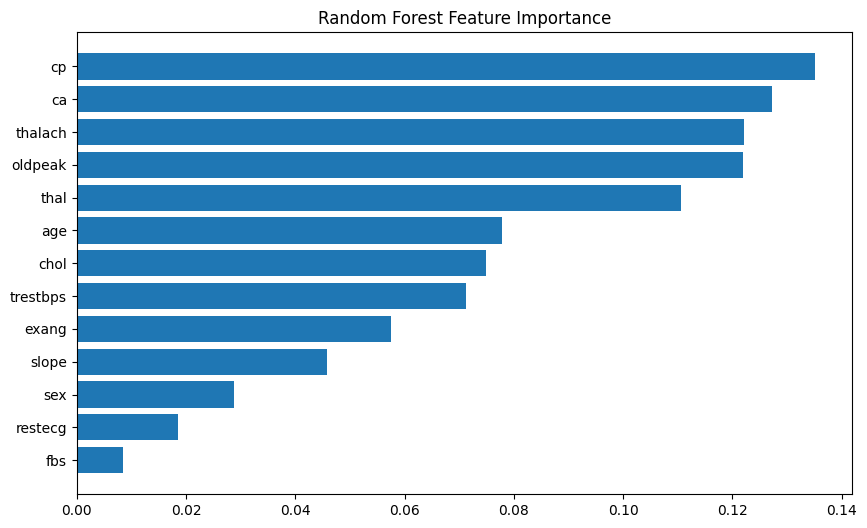

,Feature,Importance
2,cp,0.135072
11,ca,0.127327
7,thalach,0.122169
9,oldpeak,0.121905
12,thal,0.110518
0,age,0.077908
4,chol,0.074822
3,trestbps,0.071171
8,exang,0.057594
10,slope,0.045782


In [16]:

rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

importance_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()

importance_df.head(10)


In [17]:
sample = {
    'age': [65],
    'sex': [1],
    'cp': [3],
    'trestbps': [160],
    'chol': [290],
    'fbs': [1],
    'restecg': [2],
    'thalach': [105],
    'exang': [1],
    'oldpeak': [3.5],
    'slope': [0],
    'ca': [2],
    'thal': [3]
}
sample_df = pd.DataFrame(sample)

In [18]:
prediction = model_dt.predict(sample_df)

In [19]:
if prediction[0] == 1:
    print("Có khả năng bị bệnh tim.")
else:
    print("Không có khả năng bị bệnh tim.")

Không có khả năng bị bệnh tim.


## Cross Validation Evaluation

In [20]:

from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    RandomForestClassifier(random_state=42),
    x,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())


Cross Validation Scores: [1.         1.         1.         1.         0.98536585]
Mean Accuracy: 0.9970731707317073


## ROC Curve and AUC

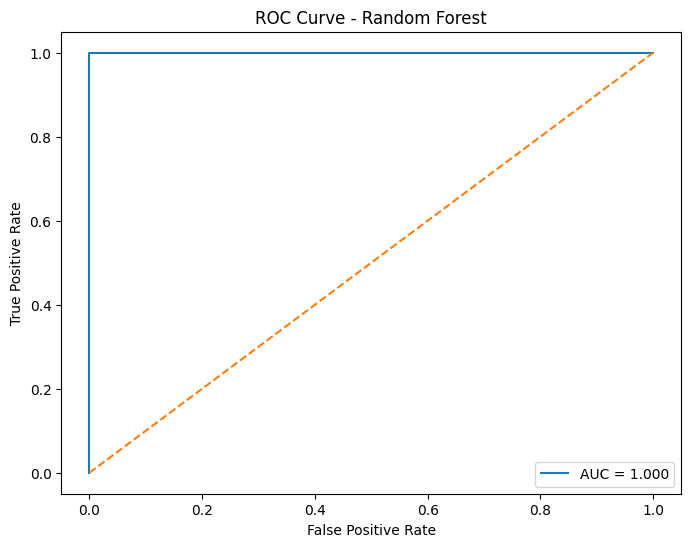

In [21]:

from sklearn.metrics import roc_curve, auc

rf = RandomForestClassifier(random_state=42)
rf.fit(x_train, y_train)

y_prob = rf.predict_proba(x_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()


In [22]:
from sklearn.metrics import accuracy_score

# Logistic Regression
accuracy_lr = accuracy_score(y_test, pred_logit)

# Random Forest
accuracy_rf = accuracy_score(y_test, pred_rf)

# KNN
accuracy_knn = accuracy_score(y_test, pred_knn)

print("Logistic Regression:", accuracy_lr)
print("Random Forest:", accuracy_rf)
print("KNN:", accuracy_knn)

Logistic Regression: 0.7951219512195122
Random Forest: 0.9853658536585366
KNN: 0.7317073170731707


In [23]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(x_train, y_train)

pred_dt = dt_model.predict(x_test)

accuracy_dt = accuracy_score(y_test, pred_dt)

## Model Comparison

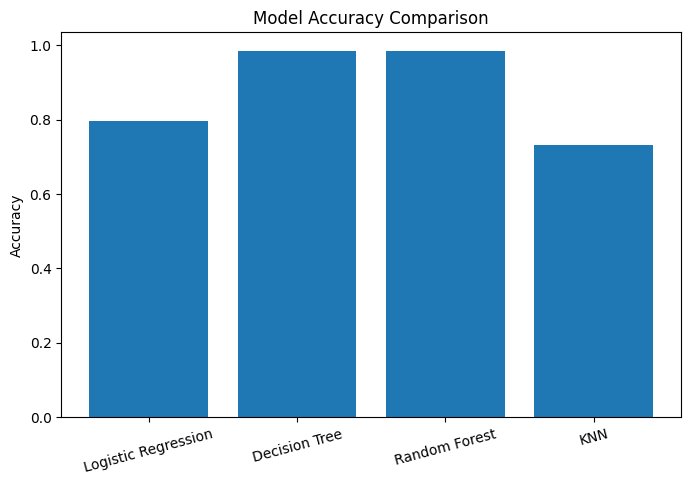

,Model,Accuracy
1,Decision Tree,0.985366
2,Random Forest,0.985366
0,Logistic Regression,0.795122
3,KNN,0.731707


In [24]:

model_names = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'KNN'
]

accuracies = [
    accuracy_lr,
    accuracy_dt,
    accuracy_rf,
    accuracy_knn
]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.show()

comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies
})

comparison_df.sort_values(by='Accuracy', ascending=False)
